# Business Problem

### Can we identify distinct recruitment behavior patterns among job postings based on salary, applicant demand, response time, and hiring outcomes?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
jobs = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Employee_Retention_Churn_Analysis\Deployment\data\processed\job_listings.csv")
recruitment = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Employee_Retention_Churn_Analysis\Deployment\data\processed\recruiting_kpis.csv")
retention = pd.read_csv(r"C:\Users\babus\Data_Spark\Project\Employee_Retention_Churn_Analysis\Deployment\data\processed\retention_kpis.csv")

In [3]:
recruitment.columns

Index(['job_id', 'num_applicants', 'avg_response_hours', 'offer_extended',
       'offer_accepted'],
      dtype='str')

In [4]:
retention.columns

Index(['job_id', 'starting_salary', 'tenure_months', 'churned_within_1yr'], dtype='str')

In [5]:
merged_df = retention.merge(recruitment,on='job_id',how="left")
final_df = merged_df.merge(jobs,on='job_id',how="left")
final_df.head()

,job_id,starting_salary,tenure_months,churned_within_1yr,num_applicants,avg_response_hours,offer_extended,offer_accepted,title,industry,...,country,city,remote_policy,experience_level,education_required,skills,tech_stack,employment_type,posted_date,application_deadline
0,2,79095.83,23,False,298,6-12,True,True,AI Researcher,Education,...,Afghanistan,Jenniferfurt,Remote,Senior,Not-specified,"Excel, Docker, JavaScript, SQL, TensorFlow, Java","Django, Flask",Internship,2023-10-22,2023-11-12
1,10,98917.21,18,False,167,6-12,True,True,AI Researcher,Retail,...,Afghanistan,Kennethtown,Remote,Director,PhD,"TensorFlow, Pandas, AWS, Docker, Python, Excel","Node.js, Spark",Contract,2025-06-14,2025-07-03
2,14,87016.68,10,True,379,6-12,True,True,AI Researcher,Technology,...,Afghanistan,Tapiaburgh,Remote,Director,PhD,"GCP, JavaScript, Excel","PostgreSQL, React, MySQL",Contract,2025-01-17,2025-02-21
3,16,89852.34,11,True,330,6-12,True,True,AI Researcher,Finance,...,Afghanistan,Sharpville,Onsite,Director,Master's,"GCP, Docker, Pandas","React, MongoDB, MySQL, Airflow, PostgreSQL",Full-time,2024-11-25,2024-12-13
4,17,65377.76,9,True,234,6-12,True,True,AI Researcher,Education,...,Afghanistan,Smithfurt,Hybrid,Director,Bachelor's,"GCP, AWS, SQL, Java, Docker, JavaScript","Spring, MySQL",Internship,2023-07-22,2023-08-23


In [6]:
final_df['skills'].value_counts()

skills
JavaScript, SQL, Excel                           30
SQL, Java, Pandas                                30
AWS, TensorFlow, Java                            28
Java, Pandas, SQL                                27
Docker, Pandas, GCP                              27
                                                 ..
SQL, Java, Kubernetes, Python, Excel, AWS         1
GCP, TensorFlow, Docker, SQL                      1
Java, TensorFlow, Docker, Kubernetes, Pandas      1
Python, Java, Kubernetes, Pandas                  1
JavaScript, SQL, Kubernetes, AWS, Docker, GCP     1
Name: count, Length: 36787, dtype: int64

In [7]:
final_df['tech_stack'].value_counts()

tech_stack
React, Spark                                213
MongoDB, MySQL                              207
React, Node.js                              201
Spring, PostgreSQL                          200
Spark, MongoDB                              197
                                           ... 
Spark, MySQL, Flask, Django, React            1
Airflow, Flask, React, PostgreSQL, Spark      1
Django, MySQL, Flask, Airflow, Spark          1
Django, PostgreSQL, Flask, MySQL, Spring      1
Spark, Flask, MongoDB, Django, Airflow        1
Name: count, Length: 17781, dtype: int64

In [8]:
cluster_cols = [
    "starting_salary",
    "num_applicants",
    "avg_response_hours"
]

In [9]:
cluster_df = final_df[cluster_cols].copy()

In [10]:
numeric_cols = [
    "starting_salary",
    "num_applicants"
]

categorical_cols = [
     "avg_response_hours"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [11]:
X_cluster = preprocessor.fit_transform(cluster_df)

In [12]:
mlb_skills = MultiLabelBinarizer()

skills_list = (
    final_df["skills"]
    .fillna("")
    .apply(lambda x: [skill.strip() for skill in x.split(",") if skill.strip()])
)


skills_encoded = mlb_skills.fit_transform(skills_list)

In [13]:
mlb_tech = MultiLabelBinarizer()

tech_list = (
    final_df["tech_stack"]
    .fillna("")
    .apply(lambda x: [tech.strip() for tech in x.split(",") if tech.strip()])
)

tech_encoded = mlb_tech.fit_transform(tech_list)

In [14]:
tech_encoded.shape

(62426, 10)

In [15]:
print("X_cluster:", X_cluster.shape)
print("Skills:", skills_encoded.shape)
print("Tech:", tech_encoded.shape)

X_cluster: (62426, 6)
Skills: (62426, 11)
Tech: (62426, 10)


In [16]:
X_final = np.hstack([
    X_cluster,
    skills_encoded,
    tech_encoded
])

In [17]:
print("Shape:", X_final.shape)
print("Data type:", type(X_final))

Shape: (62426, 27)
Data type: <class 'numpy.ndarray'>


In [18]:
print("X_cluster:", X_cluster.shape)
print("Skills:", skills_encoded.shape)
print("Tech:", tech_encoded.shape)
print("Final:", X_final.shape)

X_cluster: (62426, 6)
Skills: (62426, 11)
Tech: (62426, 10)
Final: (62426, 27)


In [19]:
np.isnan(X_final).sum()

np.int64(0)

In [20]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_final)

In [21]:
final_df["cluster"] = cluster_labels

In [22]:
final_df["cluster"].value_counts()

cluster
1    31256
0    31170
Name: count, dtype: int64

In [23]:
silhouette = silhouette_score(
    X_final,
    cluster_labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.09437182709815509


In [26]:
K_range = range(2, 11)

silhouette_scores = []

for k in K_range:

    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_temp.fit_predict(X_cluster)

    score = silhouette_score(X_cluster, labels)

    silhouette_scores.append(score)

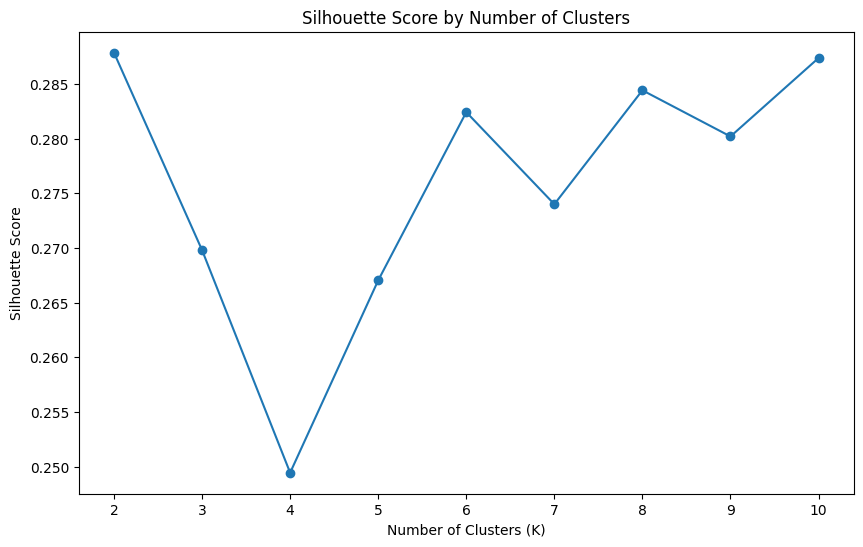

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.show()

In [28]:
silhouette_scores

[0.28784308421025573,
 0.2697967416905213,
 0.2494530495266008,
 0.2670360344163697,
 0.2824103658431931,
 0.27399572800764255,
 0.2844086445359144,
 0.28018915678544953,
 0.2873583236592115]

In [29]:
final_df["cluster"].value_counts()

cluster
0    31248
1    31178
Name: count, dtype: int64

In [30]:
final_df["cluster"].value_counts(normalize=True).mul(100).round(2)

cluster
0    50.06
1    49.94
Name: proportion, dtype: float64

In [31]:
final_df.groupby("cluster")[
    ["starting_salary", "num_applicants"]
].agg(["mean", "median", "std"]).round(2)

starting_salary                     num_applicants              
                   mean    median       std           mean median    std
cluster                                                                 
0              84991.44  85051.18  14927.91         376.86  377.0  71.81
1              84946.90  84959.09  15023.02         128.29  128.0  71.51

In [32]:
pd.crosstab(
    final_df["cluster"],
    final_df["avg_response_hours"],
    normalize="index"
).round(3)

avg_response_hours,0-6,12-18,18-24,6-12
cluster,,,,
0,0.094,0.249,0.004,0.653
1,0.094,0.242,0.004,0.661


In [34]:
cluster_profile = final_df.groupby("cluster").agg(
    avg_salary=("starting_salary", "mean"),
    median_salary=("starting_salary", "median"),
    avg_applicants=("num_applicants", "mean"),
    median_applicants=("num_applicants", "median")
).round(2)

cluster_profile

,avg_salary,median_salary,avg_applicants,median_applicants
cluster,,,,
0,84991.44,85051.18,376.86,377.0
1,84946.90,84959.09,128.29,128.0


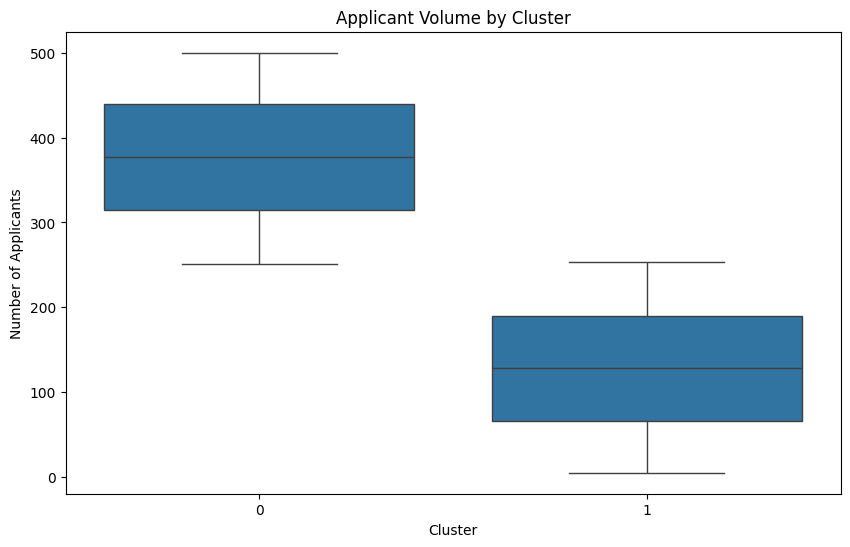

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=final_df,
    x="cluster",
    y="num_applicants"
)

plt.title("Applicant Volume by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Applicants")

plt.show()

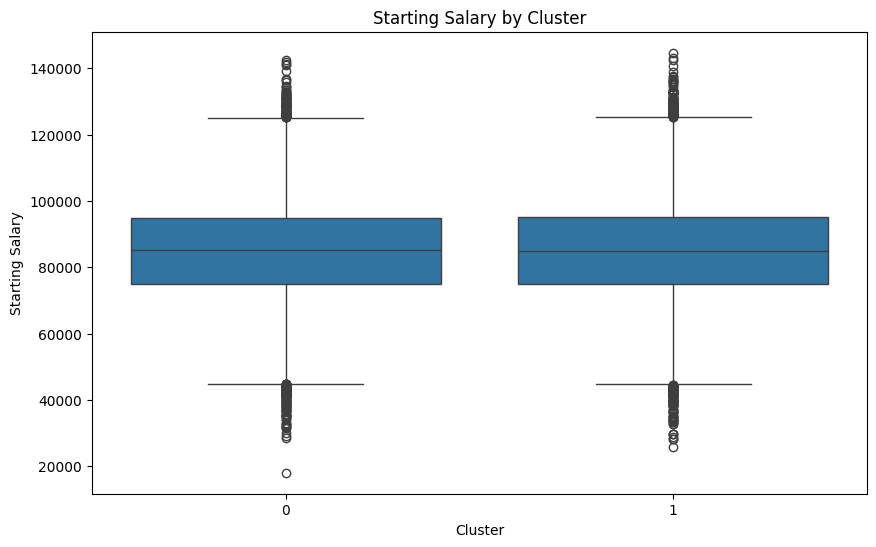

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=final_df,
    x="cluster",
    y="starting_salary"
)

plt.title("Starting Salary by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Starting Salary")

plt.show()

## what actually distinguishes Cluster 0 from Cluster 1

In [37]:
response_profile = pd.crosstab(
    final_df["cluster"],
    final_df["avg_response_hours"],
    normalize="index"
).mul(100).round(2)

response_profile

avg_response_hours,0-6,12-18,18-24,6-12
cluster,,,,
0,9.41,24.95,0.37,65.27
1,9.38,24.20,0.37,66.05


# key business insight